# Laboratorio de regresión logística

|                |   |
:----------------|---|
| **Nombre**     |Santiago Escutia Ríos   |
| **Fecha**      | 8/3/2026  |
| **Expediente** |757839   |

La regresión logística es una herramienta utilizada para predecir respuestas cualitativas. Al igual que la regresión lineal, es un método sencillo que sirve como un punto de partida para técnicas más avanzadas. Por ejemplo, lo que se conoce como *redes neuronales* o *red de perceptrones multicapa* no es más que una estructura de regresiones logísticas que se alimentan entre sí.

1. Descarga el archivo de créditos y carga los datos (Default.csv). Utiliza `pandas`.

In [16]:
import pandas as pd
df= pd.read_csv("Default.csv")

2. Utiliza el comando `obj.head()`, donde `obj` es el nombre que le diste a los datos del archivo.

In [17]:
df.head()

,default,student,balance,income
0,No,No,729.526495,44361.625074
1,No,Yes,817.180407,12106.134700
2,No,No,1073.549164,31767.138950
3,No,No,529.250605,35704.493940
4,No,No,785.655883,38463.495880


El comando head arroja los primeras *n* líneas (por defecto 5) de los datos que están en el DataFrame.

3. Utiliza el comando `obj.describe()`.

In [18]:
df.describe()

,balance,income
count,10000.000000,10000.000000
mean,835.374886,33516.981876
std,483.714985,13336.639563
min,0.000000,771.967729
25%,481.731105,21340.462903
50%,823.636973,34552.644802
75%,1166.308386,43807.729275
max,2654.322576,73554.233500


El comando describe toma las columnas que tienen datos numéricos y saca datos estadísticos comunes:
- *n*
- media
- desviación estándar
- valor mínimo
- primer cuartil
- mediana
- tercer cuartil
- valor máximo

3. Vistos estos datos, ¿qué columnas existen en el DataFrame? ¿Qué tipo de datos contienen?

Están las columnas "balance" e "income", estas dos tienen variables cuantitativas, también están las columnas "default" y "student" pero estas tienen variables de tipo cualitativa.

4. Configura el tipo de dato de las columnas `default` y `student` para cambiarlos a variables categóricas.

`data[columna] = data[columna].astype("category")`

In [19]:
df['default'] = df['default'].astype("category")

df['student'] = df['student'].astype("category")

Imagina que trabajas en un banco y que se te entregan estos datos. Tu objetivo es crear un modelo que ayude a predecir si una persona que solicita un crédito lo va a pagar. Exploremos los datos un poco más antes de crear un modelo.

Veamos primero cómo es la distribución de los valores cuando una persona dejó de pagar y cuando siguió pagando. `Default` es el término utilizado para cuando una persona dejó de pagar.

5. Crea una gráfica de caja para las columnas `income` y `balance`, con los datos agrupados con la columna `default`. Utiliza el comando `obj.boxplot(column=____, by=_____)`

<Axes: title={'center': 'income'}, xlabel='default'>

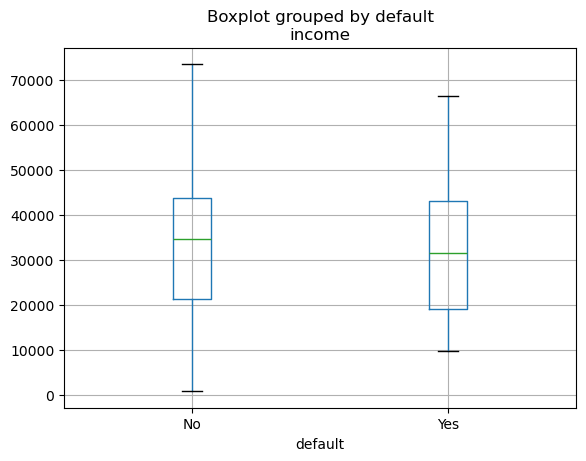

In [20]:
df.boxplot(column='income', by='default')

<Axes: title={'center': 'balance'}, xlabel='default'>

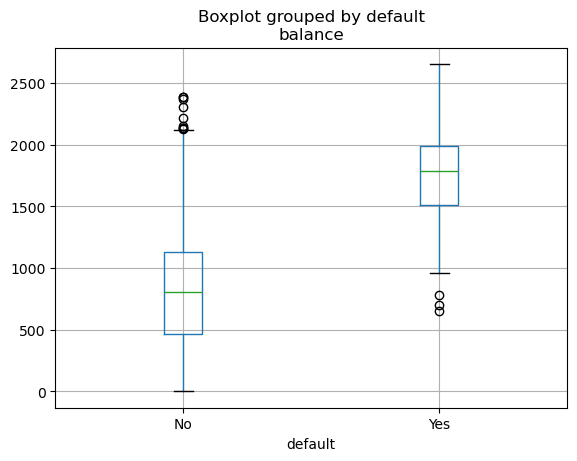

In [21]:
df.boxplot(column='balance', by='default')

6. Crea una gráfica de dispersión donde el eje *x* sea la columna `balance` y el eje *y* la columna `income`. Utiliza el comando `obj.plot.scatter(x, y, c="default", colormap="PiYG_r", alpha=0.5)`.

<Axes: xlabel='balance', ylabel='income'>

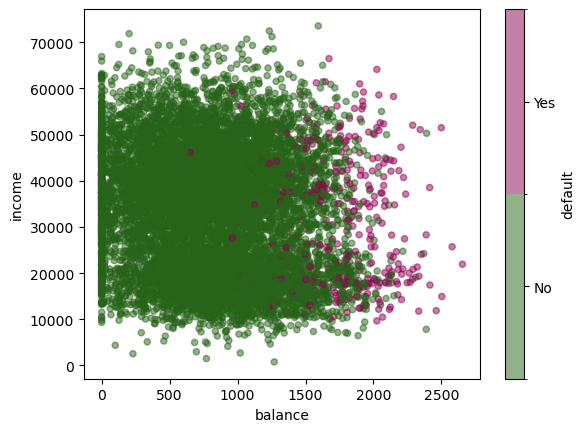

In [22]:
df.plot.scatter(x='balance', y='income', c='default', colormap='PiYG_r', alpha=0.5)

La regresión (lineal o logística) se usa para encontrar una línea que ajuste los datos para tomar una decisión. La línea que buscamos en regresión logística es aquella que nos ayude a separar las diferentes categorías. 

<img style="float: left; " src="https://www.baeldung.com/wp-content/uploads/sites/4/2023/10/decision_boundary_curve.jpg" width="400px" />


## Regresión logística simple

Creemos un modelo simple donde sólo utilizamos una de los factores para predecir una respuesta. Quiero conocer la probabilidad de que una persona deje de pagar su crédito dado el balance que tiene en su cuenta.

$$ P(\text{default}=\text{Yes}|\text{balance}) $$

Por el momento la columna default no contiene valores numéricos, por lo que hay que transformar los datos. Como default es nuestra variable de respuesta (lo que queremos predecir) podemos nombrarla *y*.

Ejecuta el código `y = obj["default"] == "Yes"`. Extrae el factor `balance` en una variable *x*.

In [23]:
y = df["default"] == "Yes"
X = df[["balance"]]

Crea un gráfico de dispersión donde el eje *x* sea `balance` y el eje *y* sea `default` transformado.

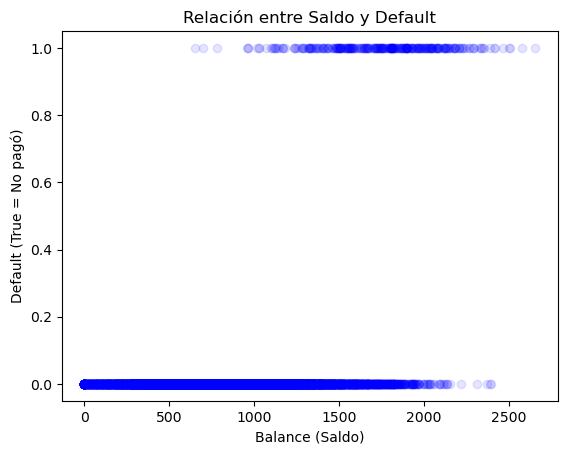

In [24]:
import matplotlib.pyplot as plt
plt.scatter(df['balance'], y, alpha=0.1, color='blue')

plt.xlabel('Balance (Saldo)')
plt.ylabel('Default (True = No pagó)')
plt.title('Relación entre Saldo y Default')
plt.show()

La línea que utilizaremos para predecir la probabilidad es:

$$ p(x) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x)}} $$

Para nuestro ejemplo de pagos y balance:

$$ P(\text{default}=1|\text{balance}) = \frac{1}{1 + e^{-(\beta_0 + \beta_1  \text{balance})}} $$

Buscamos maximizar la probabilidad de que el modelo tome decisiones correctas. Es decir, que cuando `default` fue verdadero, que la predicción sea 100%, y que cuando `default` fue falso que la predicción sea 0%.

$$ \Pi_{i:y_i=1} p(x_i) \Pi_{i':y_{i'}} (1-p(x_{i'})) $$

La función de costo ya simplificada es la siguiente:

$$ J(\vec{\beta}) = -  \sum_{i=1}^n{[y_i \ln{(\hat{p}(x_i))} + (1-y_i)\ln{(1 - \hat{p}(x_i))}]}$$

Utiliza la clase `LogisticRegression` del módulo `linear_model` de la librería `sklearn` para estimar los parámetros del modelo.

In [25]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression()
clf.fit(X, y)

LogisticRegression()

In [26]:
print(f"Intercepto (Beta 0): {clf.intercept_}")
print(f"Coeficiente de Balance (Beta 1): {clf.coef_}")

Intercepto (Beta 0): [-10.65132824]
Coeficiente de Balance (Beta 1): [[0.00549892]]


Muchos aspectos de la regresión logística son similares a la regresión lineal. Podemos medir la precisión de nuestros estimados calculando sus errores estándar. El objetivo de calcular estos errores es asegurar que hay una relación estadísticamente significativa entre el factor y la variable de respuesta.

Los errores estándar se obtienen con el siguiente procedimiento:

1. Calcula las predicciones utilizando los $\beta_0$ y $\beta_1$ encontrados.

In [27]:
import statsmodels.api as sm
X_sm = sm.add_constant(X)

model_sm = sm.Logit(y, X_sm).fit()
print(model_sm.summary())

Optimization terminated successfully.
         Current function value: 0.079823
         Iterations 10
                           Logit Regression Results                           
Dep. Variable:                default   No. Observations:                10000
Model:                          Logit   Df Residuals:                     9998
Method:                           MLE   Df Model:                            1
Date:                Sun, 08 Mar 2026   Pseudo R-squ.:                  0.4534
Time:                        19:46:21   Log-Likelihood:                -798.23
converged:                       True   LL-Null:                       -1460.3
Covariance Type:            nonrobust   LLR p-value:                6.233e-290
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -10.6513      0.361    -29.491      0.000     -11.359      -9.943
balance        0.0055      0

In [31]:
p = clf.predict_proba(X)[:, 1]
print(p[:5])

[0.00130568 0.0021126  0.00859475 0.00043444 0.00177696]


2. Idealmente la probabilidad debería ser 100% o 0%. Si alguna predicción no fue absoluta significa que hay incertidumbre. Calcula $p(1-p)$ para todas tus predicciones.

In [32]:
incertidumbre = predicciones_p * (1 - predicciones_p)
print(incertidumbre.head())

0    0.001304
1    0.002108
2    0.008521
3    0.000434
4    0.001774
dtype: float64


3. Crea una matriz vacía y llena la diagonal con las probabilidades encontradas.

`V = np.diagflat(*p(1-p)*)`

In [33]:
import numpy as np
incertidumbre = predicciones_p * (1 - predicciones_p)

V = np.diagflat(incertidumbre)
print(f"Dimensiones de la matriz V: {V.shape}")

Dimensiones de la matriz V: (10000, 10000)


4. Calcula la matriz de covarianza. (Dado que X es la matriz que contiene todos los factores)

`cov = np.linalg.inv(X.T @ V @ X)`

In [35]:
import numpy as np
xtvx = X_sm.T @ V @ X_sm

cov = np.linalg.inv(xtvx)

print("Matriz de Covarianza:")
print(cov)

Matriz de Covarianza:
[[ 1.30442848e-01 -7.81757783e-05]
 [-7.81757783e-05  4.85656859e-08]]


5. Los valores en la diagonal de la matriz de covarianza corresponden a la varianza de los factores. Utiliza los valores de la diagonal para calcular el error estándar.

`se = np.sqrt(np.diag(cov))`

In [37]:
import numpy as np

# Extrae la diagonal y calcula la raíz cuadrada
se = np.sqrt(np.diag(cov))

print(f"Error estándar del Intercepto (Beta 0): {se[0]}")
print(f"Error estándar del Balance (Beta 1): {se[1]}")

Error estándar del Intercepto (Beta 0): 0.3611687252544679
Error estándar del Balance (Beta 1): 0.00022037623717852215


Ahora, revisemos si los estimados de nuestros coeficientes demuestran que hay una relación significativa entre los factores y la respuesta.

Calculamos el estadístico *z*

$$ z_j = \frac{\hat{\beta_j}}{\text{SE}(\hat{\beta_j})} $$

In [39]:
betas = model_sm.params

# Aplicamos la fórmula: z = beta / SE
z_values = betas / se

print("Valores de Z:")
print(z_values)

Valores de Z:
const     -29.491287
balance    24.952404
dtype: float64


Utilizamos el estadístico *z* para encontrar el *p-value*.

`from scipy.stats import norm`

`p_value = 2 * (1 - norm.cdf(abs(z_statistic)))`

In [41]:
from scipy.stats import norm

# Calculamos el p-value para cada coeficiente
p_values = 2 * (1 - norm.cdf(np.abs(z_values)))

print("Valores P (P-values):")
print(p_values)

Valores P (P-values):
[0. 0.]


¿Es significativa la relación de los factores con la variable de respuesta?

Sí, es significativa ya que el p value es menor a 0.05 demostrando de que la relacion entre el balance y el impago no es casualidad.

Repite el procedimiento con el factor `student`. 
1. Transforma el factor de {"Yes", "No"} a {1, 0}.
2. Estima los coeficientes. 
3. Calcula el error estándar de tus estimaciones.
   1. Usa tu modelo para encontrar $\hat{p}(X)$
   2. Calcula el error $p(1-p)$
   3. Calcula la matriz de covarianza
   4. Extrae el error estándar
5. Argumenta si los factores son significativos utilizando el *p-value*.
   1. Utiliza el error estándar para calcular el estadístico *z*
   2. Calcula el *p-value*
   3. ¿Son significativos?


*1. Transformar el factor de {"Yes", "No"} a {1, 0}.*

In [42]:
df['student_binary'] = df['student'].map({'Yes': 1, 'No': 0})

X_student = sm.add_constant(df['student_binary'])
y = df['default'].map({'Yes': 1, 'No': 0})

*2. Estimar los coeficientes.*

In [43]:
import statsmodels.api as sm

modelo_student = sm.Logit(y, X_student).fit()
betas_student = modelo_student.params
print(betas_student)

Optimization terminated successfully.
         Current function value: 0.145434
         Iterations 7
const            -3.504128
student_binary    0.404887
dtype: float64


*3. Calcular el Error Estándar (El proceso matricial)*

*3.1 Encontrar $\hat{p}(X)$ y 3.2 Calcular $p(1-p)$**

In [44]:
# Predicciones de probabilidad
p_student = modelo_student.predict(X_student)

# Cálculo de la incertidumbre (Varianza de Bernoulli)
W_student = p_student * (1 - p_student)

*3.3 Matriz de Covarianza y 3.4 Extraer Error Estándar*

In [45]:
V_student = np.diagflat(W_student)
# Matriz de covarianza: inv(X.T @ V @ X)
cov_student = np.linalg.inv(X_student.T @ V_student @ X_student)

se_student = np.sqrt(np.diag(cov_student))
print(f"Errores Estándar: {se_student}")

Errores Estándar: [0.07071318 0.11501894]


*4.1 Calcular estadístico z*

In [46]:
z_student = betas_student / se_student
print(f"Valores Z: {z_student}")

Valores Z: const            -49.554094
student_binary     3.520177
dtype: float64


*4.2 Calcular el p-value*

In [47]:
from scipy.stats import norm
p_values_student = 2 * (1 - norm.cdf(np.abs(z_student)))
print(f"P-values: {p_values_student}")

P-values: [0.         0.00043126]


*4.3 ¿Son significativos?*

Como el p values e menor a 0.05 se puede decir de que la relación entre ser estudiante y la probabildiad de impago es real y que no fue por azar, se puede decir que sí son significativos.

## Regresión logística múltiple

Considera ahora el caso de múltiples factores. Intentemos predecir si la persona dejará de pagar su crédito utilizando toda la información que tenemos disponible. I.e.

$$ P(\text{default}=1|\text{balance}, \text{income}, \text{student}) = \frac{1}{1 + e^{-(\beta_0 + \beta_1  \text{balance} + \beta_2 \text{income} + \beta_3 \text{student})}} $$

1. Utiliza `LogisticRegression` para estimar los coeficientes.
2. Calcula el error estándar de tus estimaciones.
3. Argumenta si los factores son significativos utilizando el *p-value*. 

In [51]:
from sklearn.linear_model import LogisticRegression
import pandas as pd
import numpy as np

X = df[['balance', 'income', 'student_binary']]
y = df['default'].map({'Yes': 1, 'No': 0})

# Creación y entrenamiento del modelo
modelo_multiple = LogisticRegression(penalty=None) 
modelo_multiple.fit(X, y)

print("Coeficientes (Betas):", modelo_multiple.coef_)
print("Intersección (Beta 0):", modelo_multiple.intercept_)

Coeficientes (Betas): [[ 5.73650527e-03  3.03344988e-06 -6.46775819e-01]]
Intersección (Beta 0): [-10.86904521]


In [52]:
# Obtenemos las probabilidades predichas
pred_probs = modelo_multiple.predict_proba(X)[:, 1]

# Matriz de diseño con columna de unos (para el intercepto)
X_design = np.hstack([np.ones((X.shape[0], 1)), X])

# Cálculo de la matriz de pesos V
V = np.diagflat(pred_probs * (1 - pred_probs))

# Matriz de covarianza e incertidumbre
cov_matrix = np.linalg.inv(X_design.T @ V @ X_design)
errores_estandar = np.sqrt(np.diag(cov_matrix))

print("Errores Estándar [Intercepto, Balance, Income, Student]:")
print(errores_estandar)

Errores Estándar [Intercepto, Balance, Income, Student]:
[4.92272650e-01 2.31904426e-04 8.20276562e-06 2.36256927e-01]


In [59]:
# Guardamos el intercepto y los coeficientes de Balance, Income y Student en un solo grupo
todos_los_betas = np.concatenate([modelo_multiple.intercept_, modelo_multiple.coef_[0]])

print("Lista de todos los Betas:")
print(todos_los_betas)

Lista de todos los Betas:
[-1.08690452e+01  5.73650527e-03  3.03344988e-06 -6.46775819e-01]


In [57]:
# Estadístico z
z_scores = todos_los_betas / errores_estandar

print("Valores Z (Fuerza de cada variable):")
print(z_scores)

Valores Z (Fuerza de cada variable):
[-22.07931969  24.73650619   0.36980819  -2.73759516]


In [60]:
from scipy.stats import norm

# P value
p_values_final = 2 * (1 - norm.cdf(np.abs(z_scores)))

print("P-values:")
print(p_values_final)

P-values:
[0.         0.         0.71152542 0.00618902]


Aquí se ve que no todos los factores son significativos. "Balance" y "student" tienen un p value menor a 0.05 lo que indica una relación real y no aleatoria ante el default por lo que sí son significativos, por su parte "Income" tuvo un p value muy mayor a 0.05 (0.71) lo que indica que una vez que conocemos el balance y si alguien es estudiante conocer el ingreso de la persona no le añade valor al modelo y que el ingreso en la probabilidad de impago puede ser casualidad por lo que aquí no es significativo.

¿Cómo sabemos qué tan bueno es el modelo? Hay cuatro posibles casos para un problema de clasificación simple:
- Era sí y se predijo sí. (Verdadero positivo **TP**)
- Era sí y se predijo no. (Falso negativo **FN**)
- Era no y se predijo sí. (Falso positivo **FP**)
- Era no y se predijo no. (Verdadero negativo **TN**)

De esos cuatro casos hay dos donde el modelo es correcto y dos donde el modelo no es correcto.

![](https://miro.medium.com/v2/resize:fit:720/format:webp/1*IuymDnZpRlkat0qejE26Nw.png)

1. Menciona dos ejemplos donde consideres que un falso positivo sea un peor resultado que un falso negativo.

En el recocimiento facial de un teléfono porque es peor que el teléfono se equivoque con la cara de un extraño pensando que era la perosna correcta a que simplemente el dueño del teléfono no lo pueda desbloquear porque el celular no está seguro.

En prubas de dopaje en el deporte porque es peor que a un atleta que está limpio le digan que no lo es y dañen su reputación a que solo sí haya hecho trampa pero no se supo, aquí es injusto pero es peor el primer escenario.

2. Menciona dos ejemplos donde consideres que un falso negativo sea un peor resultado que un falso positivo.

En el diagnóstico de cáncer porque es peor que a alguien le digan que no tiene cáncer cuando en realidad sí tiene porque la enfermedad empeora y hay menos probalidades de sobrevivir que a que le digan que sí tiene cáncer no teniendo porque aquí solo está el susto pero se pueden hacer más pruebas y en sí no hay enfermedad.

Una alarma de sismo porque es peor que el sistema detecte que no hay nada raro cuando sí lo hay que a que haya una señal de potencial sismo pero el sistema no lo detecte, podrían haber muchas pérdidas humanas.

## Referencia

James, G., Witten, D., Hastie, T., Tibshirani, R.,, Taylor, J. (2023). An Introduction to Statistical Learning with Applications in Python. Cham: Springer. ISBN: 978-3-031-38746-3